In [1]:
import numpy as np
import pandas as pd

from nilearn import datasets, plotting
from nilearn.connectome import ConnectivityMeasure

import networkx as nx
import matplotlib.pyplot as plt


In [2]:
abide = datasets.fetch_abide_pcp(
    data_dir="./abide_data",
    pipeline="cpac",
    derivatives=["rois_cc200"],
    quality_checked=True,
    SITE_ID="NYU",
    n_subjects=30
)

abide.keys(), len(abide.rois_cc200)


[fetch_abide_pcp] Dataset found in abide_data/ABIDE_pcp

(dict_keys(['description', 'phenotypic', 'rois_cc200']), 30)

In [3]:
rois = abide.rois_cc200 
pheno = abide.phenotypic 

print("n_subjects:", len(rois))
print("phenotypic columns:", list(pheno.columns)[:15], "...")
print("type(rois[0]):", type(rois[0]), "shape:", np.asarray(rois[0]).shape)

n_subjects: 30
phenotypic columns: ['i', 'Unnamed: 0', 'SUB_ID', 'X', 'subject', 'SITE_ID', 'FILE_ID', 'DX_GROUP', 'DSM_IV_TR', 'AGE_AT_SCAN', 'SEX', 'HANDEDNESS_CATEGORY', 'HANDEDNESS_SCORES', 'FIQ', 'VIQ'] ...
type(rois[0]): <class 'numpy.ndarray'> shape: (176, 200)


In [4]:
def ensure_TN(ts, n_rois=200):
    
    ts = np.asarray(ts)

    if ts.ndim != 2:
        raise ValueError(f"Expected 2D array, got shape {ts.shape}")

    # اگر ستون‌ها ROI نبودند، ترنسپوز کن
    if ts.shape[1] != n_rois and ts.shape[0] == n_rois:
        ts = ts.T

    # چک نهایی (fail fast)
    if ts.shape[1] != n_rois:
        raise ValueError(
            f"Unexpected shape after processing: {ts.shape}. "
            f"Expected (T, {n_rois})."
        )

    return ts


ts0 = ensure_TN(rois[0], n_rois=200)
print("ts0 shape (T, N):", ts0.shape)


ts0 shape (T, N): (176, 200)


In [5]:
conn = ConnectivityMeasure(kind="correlation")  # Pearson correlation

C0 = conn.fit_transform([ts0])[0]  # (N, N)
print("C0 shape:", C0.shape, "| min/max:", C0.min(), C0.max())


C0 shape: (200, 200) | min/max: -0.5169379502789341 1.0


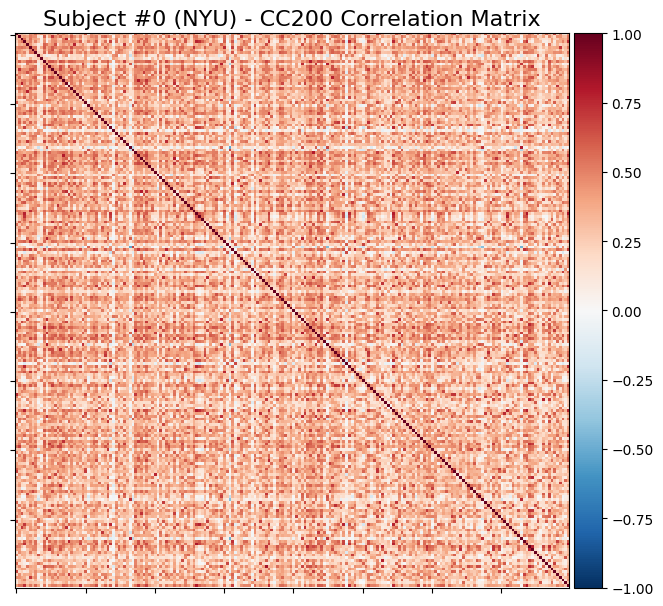

In [6]:
plotting.plot_matrix(
    C0, figure=(6, 6),
    vmin=-1, vmax=1,
    title="Subject #0 (NYU) - CC200 Correlation Matrix"
)
plt.show()


In [7]:
def corr_to_graph(C, tau=0.25, use_abs=True):
    
    A = C.copy()
    np.fill_diagonal(A, 0)

    if use_abs:
        A[np.abs(A) < tau] = 0
    else:
        A[A < tau] = 0

    G = nx.from_numpy_array(A)
    return G, A

tau = 0.25
G0, A0 = corr_to_graph(C0, tau=tau, use_abs=True)

print("Nodes:", G0.number_of_nodes())
print("Edges:", G0.number_of_edges())


Nodes: 200
Edges: 13171


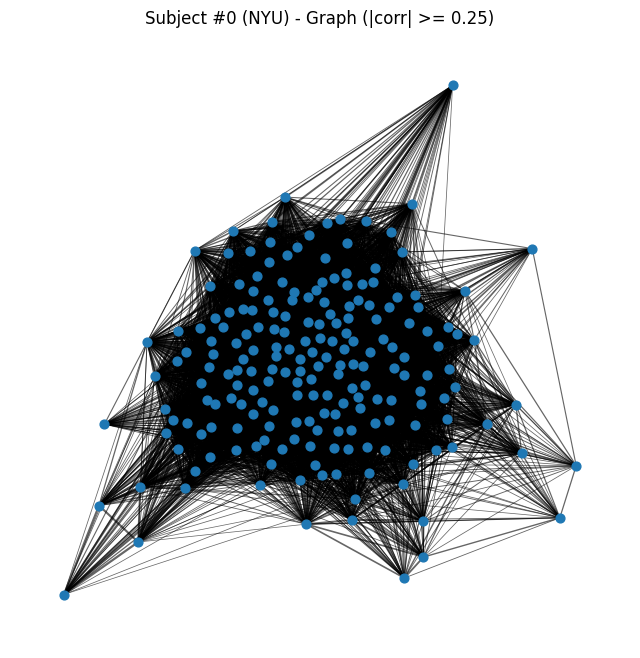

In [8]:
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(G0, seed=42, k=0.15)

weights = np.array([abs(G0[u][v]["weight"]) for u, v in G0.edges()])
if len(weights) == 0:
    print("Graph has no edges. Lower tau (e.g., 0.15)!")
else:
    nx.draw_networkx_nodes(G0, pos, node_size=40)
    nx.draw_networkx_edges(G0, pos, width=weights * 2.0, alpha=0.6)
    plt.title(f"Subject #0 (NYU) - Graph (|corr| >= {tau})")
    plt.axis("off")
    plt.show()


In [ ]:
def build_connectomes(rois_list, kind="correlation"):
    conn = ConnectivityMeasure(kind=kind)
    C_list = []
    for i, ts in enumerate(rois_list):
        ts = ensure_TN(ts)
        C = conn.fit_transform([ts])[0]
        C_list.append(C)
    return np.stack(C_list, axis=0)

C_all = build_connectomes(rois, kind="correlation")
print("C_all shape (S, N, N):", C_all.shape)


C_all shape (S, N, N): (30, 200, 200)


In [10]:
import os
os.makedirs("./outputs", exist_ok=True)

np.save("./outputs/NYU_CC200_corr_matrices.npy", C_all)
pheno.to_csv("./outputs/NYU_phenotypic.csv", index=False)

print("Saved:")
print("- ./outputs/NYU_CC200_corr_matrices.npy")
print("- ./outputs/NYU_phenotypic.csv")


Saved:
- ./outputs/NYU_CC200_corr_matrices.npy
- ./outputs/NYU_phenotypic.csv


In [11]:
def upper_triangle_features(C):
    n = C.shape[0]
    iu = np.triu_indices(n, k=1)
    return C[iu]

X = np.vstack([upper_triangle_features(C_all[i]) for i in range(C_all.shape[0])])
print("Feature matrix X shape:", X.shape)  # (S, N*(N-1)/2)

Feature matrix X shape: (30, 19900)


Mean graph edges: 13538


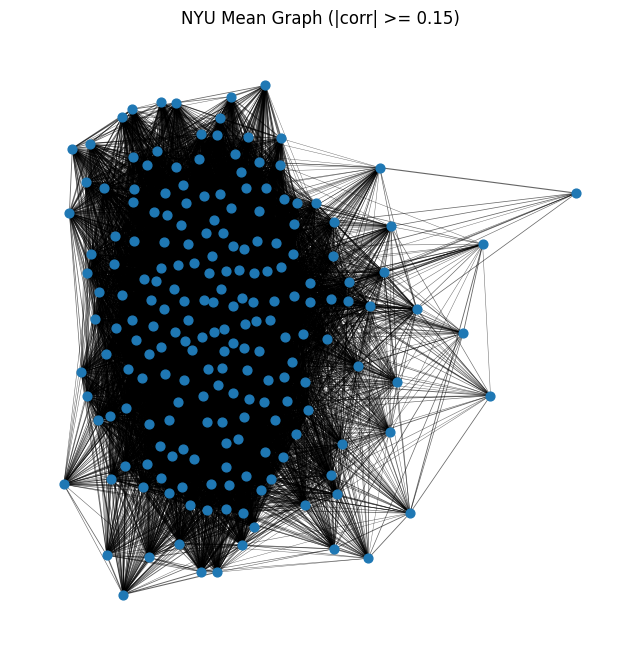

In [15]:
C_mean = C_all.mean(axis=0)

tau_mean = 0.15
G_mean, A_mean = corr_to_graph(C_mean, tau=tau_mean, use_abs=True)

print("Mean graph edges:", G_mean.number_of_edges())

plt.figure(figsize=(8, 8))
pos = nx.spring_layout(G_mean, seed=42, k=0.15)
weights = np.array([abs(G_mean[u][v]["weight"]) for u, v in G_mean.edges()])

nx.draw_networkx_nodes(G_mean, pos, node_size=40)
nx.draw_networkx_edges(G_mean, pos, width=weights * 2.0, alpha=0.6)
plt.title(f"NYU Mean Graph (|corr| >= {tau_mean})")
plt.axis("off")
plt.show()


In [16]:
def graph_basic_features(G):
    """
    Compute basic graph-level features for an undirected graph G.
    Returns a dictionary of scalar features.
    """
    n = G.number_of_nodes()
    m = G.number_of_edges()

    # Degree-related
    degrees = np.array([d for _, d in G.degree()])
    
    features = {
        "n_nodes": n,
        "n_edges": m,
        "density": nx.density(G),
        "mean_degree": degrees.mean() if n > 0 else 0,
        "max_degree": degrees.max() if n > 0 else 0,
        "std_degree": degrees.std() if n > 0 else 0,
        "n_connected_components": nx.number_connected_components(G),
    }

    # Largest connected component
    if m > 0:
        gcc = G.subgraph(max(nx.connected_components(G), key=len))
        features["gcc_size"] = gcc.number_of_nodes()
        features["gcc_fraction"] = features["gcc_size"] / n
    else:
        features["gcc_size"] = 0
        features["gcc_fraction"] = 0

    return features


In [17]:
features_subject0 = graph_basic_features(G0)

for k, v in features_subject0.items():
    print(f"{k:25s}: {v}")


n_nodes                  : 200
n_edges                  : 13171
density                  : 0.661859296482412
mean_degree              : 131.71
max_degree               : 186
std_degree               : 35.73563907361949
n_connected_components   : 1
gcc_size                 : 200
gcc_fraction             : 1.0


In [18]:
features_mean = graph_basic_features(G_mean)

for k, v in features_mean.items():
    print(f"{k:25s}: {v}")


n_nodes                  : 200
n_edges                  : 13538
density                  : 0.6803015075376885
mean_degree              : 135.38
max_degree               : 195
std_degree               : 34.78714705174887
n_connected_components   : 1
gcc_size                 : 200
gcc_fraction             : 1.0


In [19]:
def clustering_features(G):
    return {
        "mean_clustering": nx.average_clustering(G),
        "clustering_per_node": np.array(list(nx.clustering(G).values()))
    }

clust_sub0 = clustering_features(G0)
clust_mean = clustering_features(G_mean)

print("Subject #0 mean clustering:", clust_sub0["mean_clustering"])
print("Mean graph clustering:", clust_mean["mean_clustering"])


Subject #0 mean clustering: 0.8022879148206664
Mean graph clustering: 0.8079195939780061


In [20]:
def path_based_features(G):
    if G.number_of_edges() == 0:
        return {"avg_shortest_path": np.nan, "global_efficiency": 0}

    gcc = G.subgraph(max(nx.connected_components(G), key=len))

    feats = {}
    if gcc.number_of_nodes() > 1:
        feats["avg_shortest_path"] = nx.average_shortest_path_length(gcc)
        feats["global_efficiency"] = nx.global_efficiency(gcc)
    else:
        feats["avg_shortest_path"] = np.nan
        feats["global_efficiency"] = 0

    return feats

path_sub0 = path_based_features(G0)
path_mean = path_based_features(G_mean)

print("Subject #0:", path_sub0)
print("Mean graph:", path_mean)


Subject #0: {'avg_shortest_path': 1.3385427135678392, 'global_efficiency': 0.830862646566164}
Mean graph: {'avg_shortest_path': 1.3197487437185929, 'global_efficiency': 0.840142378559464}


In [21]:
G = G0


def get_transition_probs(G, node):
    neigh = list(G.neighbors(node))
    if len(neigh) == 0:
        return neigh, None

    w = []
    for v in neigh:
        w_ij = G[node][v].get("weight", 1.0)
        w.append(abs(w_ij)) 
    w = np.array(w, dtype=float)

    
    if w.sum() == 0:
        p = np.ones_like(w) / len(w)
    else:
        p = w / w.sum()
    return neigh, p


In [22]:
def random_walk(G, start_node=None, walk_length=200, seed=42):
    rng = np.random.default_rng(seed)

    nodes = list(G.nodes())
    if start_node is None:
        start_node = int(rng.choice(nodes))

    path = [start_node]
    cur = start_node

    for _ in range(walk_length):
        neigh, p = get_transition_probs(G, cur)

        
        if len(neigh) == 0:
            cur = int(rng.choice(nodes))
            path.append(cur)
            continue

        cur = int(rng.choice(neigh, p=p))
        path.append(cur)

    return path

# چند walk نمونه
paths = [random_walk(G, start_node=None, walk_length=300, seed=100+i) for i in range(5)]
print("Example path (first 30 steps):")
print(paths[0][:30])


Example path (first 30 steps):
[153, 109, 50, 5, 195, 110, 155, 173, 135, 38, 196, 54, 120, 109, 111, 91, 199, 94, 154, 91, 199, 194, 88, 61, 170, 149, 134, 66, 65, 21]


In [23]:
from collections import Counter

def visit_counts_from_paths(paths):
    cnt = Counter()
    for p in paths:
        cnt.update(p)
    return cnt

visit_cnt = visit_counts_from_paths(paths)

# نمایش 15 نود پر بازدید
top15 = visit_cnt.most_common(15)
top15


[(170, 17),
 (82, 16),
 (28, 16),
 (54, 15),
 (149, 15),
 (151, 15),
 (59, 15),
 (110, 14),
 (14, 14),
 (62, 14),
 (68, 14),
 (95, 14),
 (5, 13),
 (196, 13),
 (91, 13)]

In [24]:
def many_random_walks(G, n_walks=200, walk_length=500, seed=123):
    rng = np.random.default_rng(seed)
    nodes = list(G.nodes())

    all_visits = Counter()
    for i in range(n_walks):
        start = int(rng.choice(nodes))
        p = random_walk(G, start_node=start, walk_length=walk_length, seed=seed+i)
        all_visits.update(p)
    return all_visits

visits = many_random_walks(G, n_walks=300, walk_length=600, seed=2024)

# تبدیل به توزیع (احتمال)
total = sum(visits.values())
stationary_hat = {k: v/total for k, v in visits.items()}

# top 20 nodes in stationary estimate
top20_stationary = sorted(stationary_hat.items(), key=lambda x: x[1], reverse=True)[:20]
top20_stationary


[(78, 0.008191902384914032),
 (64, 0.008042151968940654),
 (106, 0.008019966722129783),
 (10, 0.007975596228508042),
 (110, 0.007864669994453689),
 (47, 0.007820299500831946),
 (20, 0.007670549084858569),
 (149, 0.007465335551858014),
 (122, 0.007437603993344426),
 (43, 0.00742651136993899),
 (199, 0.0073765945646145316),
 (13, 0.007359955629506378),
 (96, 0.00735440931780366),
 (44, 0.007243483083749306),
 (95, 0.007237936772046589),
 (7, 0.007226844148641154),
 (5, 0.0071602884082085415),
 (75, 0.007127010537992235),
 (17, 0.007093732667775929),
 (28, 0.006988352745424293)]

In [25]:
print("Phenotypic columns (sample):", list(pheno.columns)[:30])

# رایج‌ترین حالت:
if "DX_GROUP" in pheno.columns:
    # ABIDE: 1 = Autism, 2 = Control
    y = (pheno["DX_GROUP"].values == 1).astype(int)  # 1=ASD, 0=Control
    print("Using DX_GROUP. y counts:", np.bincount(y), "(0=Control, 1=ASD)")
else:
    # اگر DX_GROUP نبود، سعی می‌کنیم حدس بزنیم (مثلاً Group/Diagnosis)
    cand = [c for c in pheno.columns if "DX" in c.upper() or "GROUP" in c.upper() or "DIAG" in c.upper()]
    print("No DX_GROUP found. Candidate columns:", cand)
    raise ValueError("Please tell me which column indicates diagnosis (ASD vs Control).")


Phenotypic columns (sample): ['i', 'Unnamed: 0', 'SUB_ID', 'X', 'subject', 'SITE_ID', 'FILE_ID', 'DX_GROUP', 'DSM_IV_TR', 'AGE_AT_SCAN', 'SEX', 'HANDEDNESS_CATEGORY', 'HANDEDNESS_SCORES', 'FIQ', 'VIQ', 'PIQ', 'FIQ_TEST_TYPE', 'VIQ_TEST_TYPE', 'PIQ_TEST_TYPE', 'ADI_R_SOCIAL_TOTAL_A', 'ADI_R_VERBAL_TOTAL_BV', 'ADI_RRB_TOTAL_C', 'ADI_R_ONSET_TOTAL_D', 'ADI_R_RSRCH_RELIABLE', 'ADOS_MODULE', 'ADOS_TOTAL', 'ADOS_COMM', 'ADOS_SOCIAL', 'ADOS_STEREO_BEHAV', 'ADOS_RSRCH_RELIABLE']
Using DX_GROUP. y counts: [ 0 30] (0=Control, 1=ASD)


In [26]:
tau_subj = 0.25  # می‌تونی تغییر بدی (0.20 هم رایجه)
G_list = []
A_list = []

for i in range(C_all.shape[0]):
    G_i, A_i = corr_to_graph(C_all[i], tau=tau_subj, use_abs=True)
    G_list.append(G_i)
    A_list.append(A_i)

print("Built graphs:", len(G_list))
print("Example edges:", G_list[0].number_of_edges(), "tau =", tau_subj)


Built graphs: 30
Example edges: 13171 tau = 0.25


In [27]:
def pagerank_abs_weight(G, alpha=0.85):
    H = G.copy()
    for u, v, d in H.edges(data=True):
        d["w_abs"] = abs(d.get("weight", 1.0))
    pr = nx.pagerank(H, alpha=alpha, weight="w_abs")
    return pr

pr0 = pagerank_abs_weight(G0, alpha=0.85)
pr_mean = pagerank_abs_weight(G_mean, alpha=0.85)

top10_pr0 = sorted(pr0.items(), key=lambda x: x[1], reverse=True)[:10]
top10_pr_mean = sorted(pr_mean.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top10 PageRank - Subject0:", top10_pr0)
print("Top10 PageRank - MeanGraph:", top10_pr_mean)


Top10 PageRank - Subject0: [(110, 0.007529945907158082), (64, 0.007513999907566575), (10, 0.007402481659681111), (106, 0.0073818068828109375), (47, 0.007330853845481096), (78, 0.007317575787604717), (96, 0.0072741483943820325), (43, 0.0071108072784101806), (149, 0.007086165226944027), (5, 0.007070434455892141)]
Top10 PageRank - MeanGraph: [(17, 0.0076896095416065695), (36, 0.007603322228948374), (44, 0.007487235581992506), (5, 0.0072640176451725675), (47, 0.007036931026289452), (151, 0.006930959576283291), (57, 0.006847493096208205), (195, 0.006829387315529687), (191, 0.00681596371201607), (8, 0.006779921954398717)]


In [28]:

G = G_mean

# Degree (unweighted)
deg = dict(G.degree())

# Weighted degree (strength) با abs
strength = {}
for n in G.nodes():
    s = 0.0
    for nb in G.neighbors(n):
        s += abs(G[n][nb].get("weight", 1.0))
    strength[n] = s

# Betweenness (برای سرعت روی گراف mean خوبه)
btw = nx.betweenness_centrality(G, weight=None, normalized=True)

# Eigenvector centrality (ممکن است برای گراف‌های بزرگ/پراکنده کمی سخت شود)
try:
    ev = nx.eigenvector_centrality_numpy(G)  # سریع‌تر
except Exception as e:
    print("Eigenvector centrality failed:", e)
    ev = {n: np.nan for n in G.nodes()}

# PageRank
pr = pagerank_abs_weight(G)

df_nodes = pd.DataFrame({
    "node": list(G.nodes()),
    "degree": [deg[n] for n in G.nodes()],
    "strength_abs": [strength[n] for n in G.nodes()],
    "betweenness": [btw[n] for n in G.nodes()],
    "eigenvector": [ev[n] for n in G.nodes()],
    "pagerank": [pr[n] for n in G.nodes()],
})

# نمایش 15 نود برتر بر اساس pagerank
display(df_nodes.sort_values("pagerank", ascending=False).head(15))


,node,degree,strength_abs,betweenness,eigenvector,pagerank
17,17,195,54.275616,0.005190,0.094146,0.007690
36,36,191,53.454039,0.004867,0.092740,0.007603
44,44,193,52.735772,0.005032,0.093543,0.007487
5,5,184,51.435634,0.003211,0.091357,0.007264
47,47,182,48.965512,0.004118,0.089268,0.007037
151,151,194,47.976176,0.006432,0.093779,0.006931
57,57,168,47.563031,0.003219,0.082615,0.006847
195,195,184,47.355414,0.004710,0.089581,0.006829
191,191,186,47.701313,0.003644,0.091537,0.006816
8,8,186,47.357343,0.003723,0.091651,0.006780


In [29]:
Gu = nx.Graph()
Gu.add_nodes_from(G_mean.nodes())
Gu.add_edges_from(G_mean.edges())  # فقط ساختار ارتباطی

bridges = list(nx.bridges(Gu))
print("Number of bridges (mean graph):", len(bridges))
print("First 20 bridges:", bridges[:20])


Number of bridges (mean graph): 0
First 20 bridges: []


In [30]:
eb = nx.edge_betweenness_centrality(Gu, normalized=True)

top20_edges = sorted(eb.items(), key=lambda x: x[1], reverse=True)[:20]
top20_edges


[((85, 151), 0.0019623519510454175),
 ((85, 117), 0.0017025209291839077),
 ((29, 85), 0.0016555114808883683),
 ((40, 85), 0.0010911011099453342),
 ((85, 175), 0.0008327843632195585),
 ((85, 161), 0.0008171673385241225),
 ((85, 193), 0.0007669160822427155),
 ((70, 180), 0.0006764322211052692),
 ((180, 195), 0.0006759785860471602),
 ((17, 197), 0.0006120463762231112),
 ((44, 197), 0.0006055191867158038),
 ((62, 197), 0.0005644120360268505),
 ((70, 197), 0.0005623337487593428),
 ((36, 197), 0.0005485720979247123),
 ((10, 180), 0.0005392497374477638),
 ((29, 197), 0.0005301012474836935),
 ((99, 197), 0.0005100830883301754),
 ((47, 197), 0.0005056386215741508),
 ((177, 197), 0.0005015793781932992),
 ((136, 197), 0.0004971407697380908)]

In [31]:
# --- ASD-only PageRank summary (replaces ASD vs Control diff cell) ---

S = len(G_list)
N = G_list[0].number_of_nodes()

# PageRank per subject
PR = np.zeros((S, N), dtype=float)
for i, Gi in enumerate(G_list):
    pri = pagerank_abs_weight(Gi, alpha=0.85)
    PR[i, :] = np.array([pri[j] for j in range(N)])

# چون دیتاست فعلی فقط ASD است، کل PR همان PR_asd است
# (اگر بعداً دیتاستت mix شد، این خط کمک می‌کند فقط ASDها انتخاب شوند.)
PR_asd = PR[y == 1] if "y" in globals() else PR

print("ASD subjects:", PR_asd.shape[0], "| N nodes:", PR_asd.shape[1])

# Mean / Std across ASD subjects
mean_asd = PR_asd.mean(axis=0)
std_asd  = PR_asd.std(axis=0)

df_asd_pr = pd.DataFrame({
    "node": np.arange(N),
    "PR_asd_mean": mean_asd,
    "PR_asd_std": std_asd,
    "zscore": (mean_asd - mean_asd.mean()) / (mean_asd.std() + 1e-12)
}).sort_values("PR_asd_mean", ascending=False)

print("Top 20 ASD hubs by mean PageRank:")
display(df_asd_pr.head(20))

print("Bottom 20 nodes by mean PageRank:")
display(df_asd_pr.tail(20))

# --- Optional: hub stability across ASD subjects ---
topk = 20
top_sets = [set(np.argsort(PR_asd[i])[::-1][:topk]) for i in range(PR_asd.shape[0])]

from collections import Counter
cnt = Counter()
for s in top_sets:
    cnt.update(list(s))

df_stability = pd.DataFrame({
    "node": list(cnt.keys()),
    "count_in_top20": list(cnt.values()),
    "fraction_in_top20": [v / PR_asd.shape[0] for v in cnt.values()]
}).sort_values(["fraction_in_top20", "count_in_top20"], ascending=False)

print(f"Top 20 most stable hubs (appearing in Top{topk} across ASD subjects):")
display(df_stability.head(20))


ASD subjects: 30 | N nodes: 200
Top 20 ASD hubs by mean PageRank:


,node,PR_asd_mean,PR_asd_std,zscore
17,17,0.007293,0.001913,2.182462
57,57,0.007142,0.001641,2.038327
5,5,0.007126,0.001701,2.023041
12,12,0.006932,0.001227,1.838321
36,36,0.006888,0.001642,1.797012
78,78,0.006875,0.001766,1.784634
195,195,0.006806,0.002283,1.718234
118,118,0.006797,0.001502,1.710452
88,88,0.006610,0.001568,1.532118
136,136,0.006609,0.001544,1.530957


Bottom 20 nodes by mean PageRank:


,node,PR_asd_mean,PR_asd_std,zscore
193,193,0.003554,0.001424,-1.376265
198,198,0.003519,0.001689,-1.409056
86,86,0.003492,0.001394,-1.435127
144,144,0.003438,0.001781,-1.486033
41,41,0.003395,0.001302,-1.527004
134,134,0.003393,0.001226,-1.528956
20,20,0.003376,0.001325,-1.545422
159,159,0.003309,0.001471,-1.609246
189,189,0.003209,0.001204,-1.704734
129,129,0.003146,0.001185,-1.764715


Top 20 most stable hubs (appearing in Top20 across ASD subjects):


,node,count_in_top20,fraction_in_top20
0,5,17,0.566667
4,17,17,0.566667
30,57,16,0.533333
14,78,15,0.500000
69,195,15,0.500000
58,36,14,0.466667
9,44,13,0.433333
10,47,12,0.400000
39,12,12,0.400000
85,118,11,0.366667


In [32]:
rng = np.random.default_rng(0)

# PR_asd: shape (S_asd, N)
S_asd, N = PR_asd.shape

mean_asd = PR_asd.mean(axis=0)

n_perm = 2000
null_means = np.zeros((n_perm, N), dtype=float)

for b in range(n_perm):
    # برای هر سابجکت، PR را روی نودها shuffle می‌کنیم (null: hub labels random)
    PR_shuf = np.empty_like(PR_asd)
    for i in range(S_asd):
        perm = rng.permutation(N)
        PR_shuf[i] = PR_asd[i, perm]
    null_means[b] = PR_shuf.mean(axis=0)

# p-value یکطرفه: PR_mean بزرگ‌تر از null چقدر نادر است؟
pvals = np.zeros(N, dtype=float)
for node in range(N):
    pvals[node] = (np.sum(null_means[:, node] >= mean_asd[node]) + 1) / (n_perm + 1)

df_hub_sig = pd.DataFrame({
    "node": np.arange(N),
    "PR_asd_mean": mean_asd,
    "p_value_null_shuffle": pvals
}).sort_values(["p_value_null_shuffle", "PR_asd_mean"], ascending=[True, False])

display(df_hub_sig.head(20))


,node,PR_asd_mean,p_value_null_shuffle
17,17,0.007293,0.0005
57,57,0.007142,0.0005
5,5,0.007126,0.0005
12,12,0.006932,0.0005
36,36,0.006888,0.0005
78,78,0.006875,0.0005
195,195,0.006806,0.0005
118,118,0.006797,0.0005
88,88,0.006610,0.0005
136,136,0.006609,0.0005


In [33]:
def to_unweighted(G):
    Gu = nx.Graph()
    Gu.add_nodes_from(G.nodes())
    Gu.add_edges_from(G.edges())
    return Gu

EB = []  # list of dict edge->value
for i, Gi in enumerate(G_list):
    Gui = to_unweighted(Gi)
    ebi = nx.edge_betweenness_centrality(Gui, normalized=True)
    EB.append(ebi)

# همه‌ی یال‌های ممکن که در union دیده شده‌اند
all_edges = set()
for ebi in EB:
    all_edges |= set(ebi.keys())
all_edges = sorted(list(all_edges))

EB_mat = np.zeros((S, len(all_edges)), dtype=float)
for i in range(S):
    ebi = EB[i]
    EB_mat[i, :] = [ebi.get(e, 0.0) for e in all_edges]

EB_asd = EB_mat[y == 1]
EB_ctrl = EB_mat[y == 0]

diff_edge = EB_asd.mean(axis=0) - EB_ctrl.mean(axis=0)
top_idx = np.argsort(diff_edge)[::-1][:20]

top_edge_diff = [(all_edges[j], diff_edge[j]) for j in top_idx]
top_edge_diff


/var/folders/s2/hgf9wgz50zn8b1ntbdz5nhpr0000gn/T/ipykernel_37593/591343467.py:27: RuntimeWarning: Mean of empty slice.
  diff_edge = EB_asd.mean(axis=0) - EB_ctrl.mean(axis=0)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


[((198, 199), nan),
 ((197, 199), nan),
 ((197, 198), nan),
 ((196, 199), nan),
 ((196, 198), nan),
 ((196, 197), nan),
 ((195, 199), nan),
 ((195, 198), nan),
 ((195, 197), nan),
 ((195, 196), nan),
 ((194, 199), nan),
 ((194, 198), nan),
 ((194, 197), nan),
 ((194, 196), nan),
 ((194, 195), nan),
 ((193, 199), nan),
 ((193, 198), nan),
 ((193, 197), nan),
 ((193, 196), nan),
 ((193, 195), nan)]

# Control Dataset Begins


In [35]:
def fetch_n_controls_abide(
    target_controls=30,
    site_id="NYU",
    data_dir="./abide_data",
    pipeline="cpac",
    derivatives=("rois_cc200",),
    quality_checked=True,
    start_n=40,
    step=40,
    max_n=400,
):
    """
    تلاش می‌کند بدون گرفتن کل دیتاست، فقط به اندازه‌ای subject دانلود کند که
    حداقل target_controls کنترل داشته باشیم، سپس ۳۰ کنترل اول را برمی‌گرداند.
    """
    n = start_n

    last = None
    while n <= max_n:
        abide_tmp = datasets.fetch_abide_pcp(
            data_dir=data_dir,
            pipeline=pipeline,
            derivatives=list(derivatives),
            quality_checked=quality_checked,
            SITE_ID=site_id,
            n_subjects=n,
        )
        last = abide_tmp

        ph = abide_tmp.phenotypic
        if "DX_GROUP" not in ph.columns:
            raise ValueError("DX_GROUP column not found in phenotypic!")

        # ABIDE: 1=ASD, 2=Control
        ctrl_idx = np.where(ph["DX_GROUP"].values == 2)[0]
        if len(ctrl_idx) >= target_controls:
            keep = ctrl_idx[:target_controls]
            rois_ctrl = [abide_tmp.rois_cc200[i] for i in keep]
            pheno_ctrl = ph.iloc[keep].reset_index(drop=True)
            return rois_ctrl, pheno_ctrl, abide_tmp

        n += step

    raise RuntimeError(
        f"Could not find {target_controls} controls up to n_subjects={max_n}. "
        f"Last control count={(last.phenotypic['DX_GROUP'].values==2).sum() if last else 'NA'}"
    )


In [38]:
rois_ctrl, pheno_ctrl, abide_ctrl_raw = fetch_n_controls_abide(
    target_controls=30,
    site_id="NYU",
    data_dir="./abide_data",
    pipeline="cpac",
    derivatives=("rois_cc200",),
    quality_checked=True,
    start_n=40,
    step=40,
    max_n=400,
)

print("CONTROL subjects loaded:", len(rois_ctrl))
print("DX_GROUP counts in pheno_ctrl:", pheno_ctrl["DX_GROUP"].value_counts().to_dict())
print("Example ROI ts shape:", np.asarray(rois_ctrl[0]).shape)


[fetch_abide_pcp] Dataset found in abide_data/ABIDE_pcp

[fetch_abide_pcp] Dataset found in abide_data/ABIDE_pcp

[fetch_abide_pcp] Dataset found in abide_data/ABIDE_pcp

CONTROL subjects loaded: 30
DX_GROUP counts in pheno_ctrl: {2: 30}
Example ROI ts shape: (176, 200)


In [39]:
# 0 = Control, 1 = ASD (برای همخوانی با کد قبلی تو)
y_ctrl = (pheno_ctrl["DX_GROUP"].values == 1).astype(int)

print("y_ctrl bincount:", np.bincount(y_ctrl), "(0=Control, 1=ASD)")
assert y_ctrl.sum() == 0, "This should be all controls, but some ASD found!"


y_ctrl bincount: [30] (0=Control, 1=ASD)


In [40]:
required_funcs = ["ensure_TN", "corr_to_graph", "build_connectomes", "pagerank_abs_weight"]
missing = [f for f in required_funcs if f not in globals()]
if missing:
    raise NameError(f"Missing functions from previous cells: {missing}")
print("All required functions found ✅")


All required functions found ✅


In [41]:
ts0_ctrl = ensure_TN(rois_ctrl[0])

conn = ConnectivityMeasure(kind="correlation")
C0_ctrl = conn.fit_transform([ts0_ctrl])[0]

print("C0_ctrl shape:", C0_ctrl.shape, "| min/max:", C0_ctrl.min(), C0_ctrl.max())


C0_ctrl shape: (200, 200) | min/max: -0.3245613027577185 1.0


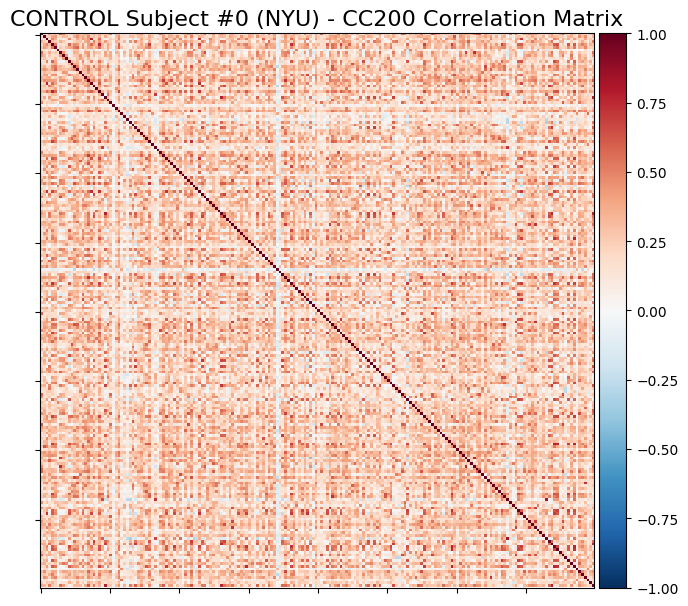

In [42]:
plotting.plot_matrix(
    C0_ctrl, figure=(6, 6),
    vmin=-1, vmax=1,
    title="CONTROL Subject #0 (NYU) - CC200 Correlation Matrix"
)
plt.show()


In [43]:
tau = 0.25
G0_ctrl, A0_ctrl = corr_to_graph(C0_ctrl, tau=tau, use_abs=True)

print("Nodes:", G0_ctrl.number_of_nodes())
print("Edges:", G0_ctrl.number_of_edges())


Nodes: 200
Edges: 8796


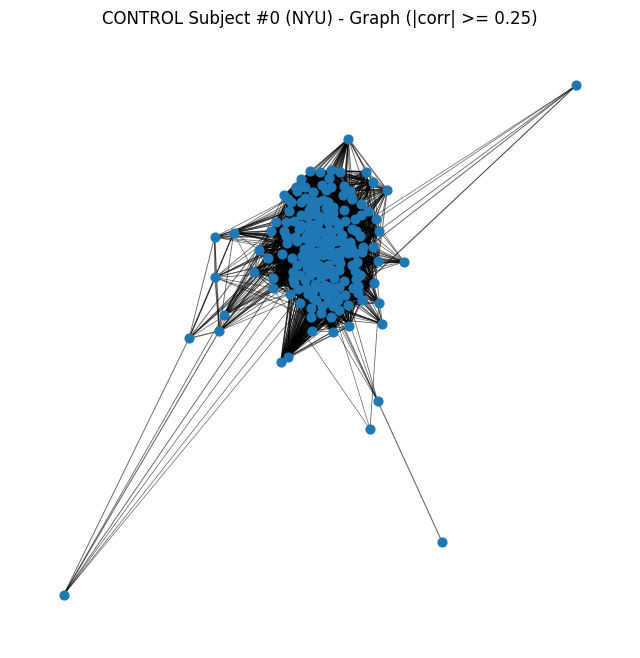

In [44]:
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(G0_ctrl, seed=42, k=0.15)

weights = np.array([abs(G0_ctrl[u][v]["weight"]) for u, v in G0_ctrl.edges()])
if len(weights) == 0:
    print("Graph has no edges. Lower tau (e.g., 0.15)!")
else:
    nx.draw_networkx_nodes(G0_ctrl, pos, node_size=40)
    nx.draw_networkx_edges(G0_ctrl, pos, width=weights * 2.0, alpha=0.6)
    plt.title(f"CONTROL Subject #0 (NYU) - Graph (|corr| >= {tau})")
    plt.axis("off")
    plt.show()


In [45]:
C_all_ctrl = build_connectomes(rois_ctrl, kind="correlation")
print("C_all_ctrl shape (S, N, N):", C_all_ctrl.shape)


C_all_ctrl shape (S, N, N): (30, 200, 200)


In [46]:
import os
os.makedirs("./outputs", exist_ok=True)

np.save("./outputs/NYU_CC200_corr_matrices_CONTROL30.npy", C_all_ctrl)
pheno_ctrl.to_csv("./outputs/NYU_phenotypic_CONTROL30.csv", index=False)

print("Saved:")
print("- ./outputs/NYU_CC200_corr_matrices_CONTROL30.npy")
print("- ./outputs/NYU_phenotypic_CONTROL30.csv")


Saved:
- ./outputs/NYU_CC200_corr_matrices_CONTROL30.npy
- ./outputs/NYU_phenotypic_CONTROL30.csv


In [47]:
def upper_triangle_features(C):
    n = C.shape[0]
    iu = np.triu_indices(n, k=1)
    return C[iu]

X_ctrl = np.vstack([upper_triangle_features(C_all_ctrl[i]) for i in range(C_all_ctrl.shape[0])])
print("Feature matrix X_ctrl shape:", X_ctrl.shape)


Feature matrix X_ctrl shape: (30, 19900)


CONTROL mean graph edges: 10323


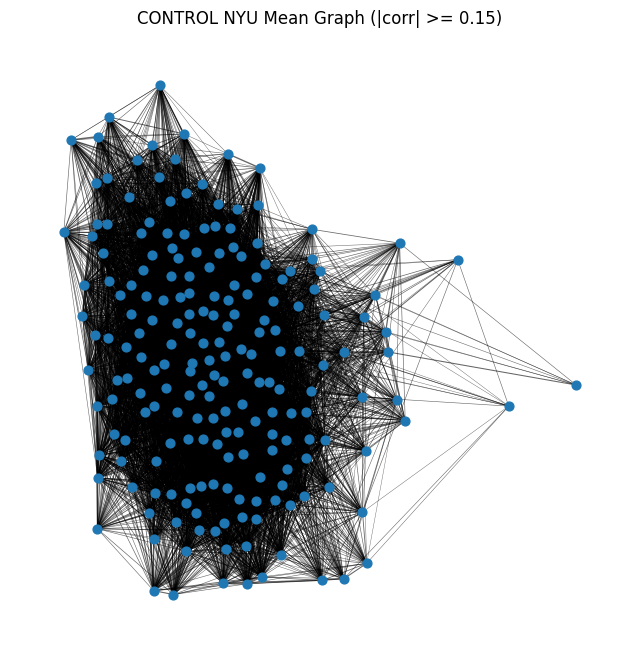

In [48]:
C_mean_ctrl = C_all_ctrl.mean(axis=0)

tau_mean = 0.15
G_mean_ctrl, A_mean_ctrl = corr_to_graph(C_mean_ctrl, tau=tau_mean, use_abs=True)

print("CONTROL mean graph edges:", G_mean_ctrl.number_of_edges())

plt.figure(figsize=(8, 8))
pos = nx.spring_layout(G_mean_ctrl, seed=42, k=0.15)
weights = np.array([abs(G_mean_ctrl[u][v]["weight"]) for u, v in G_mean_ctrl.edges()])

nx.draw_networkx_nodes(G_mean_ctrl, pos, node_size=40)
nx.draw_networkx_edges(G_mean_ctrl, pos, width=weights * 2.0, alpha=0.6)
plt.title(f"CONTROL NYU Mean Graph (|corr| >= {tau_mean})")
plt.axis("off")
plt.show()


In [49]:
features_control_subject0 = graph_basic_features(G0_ctrl)

for k, v in features_control_subject0.items():
    print(f"{k:25s}: {v}")


n_nodes                  : 200
n_edges                  : 8796
density                  : 0.4420100502512563
mean_degree              : 87.96
max_degree               : 150
std_degree               : 34.509975369449336
n_connected_components   : 1
gcc_size                 : 200
gcc_fraction             : 1.0


In [50]:
features_control_mean = graph_basic_features(G_mean_ctrl)

for k, v in features_control_mean.items():
    print(f"{k:25s}: {v}")


n_nodes                  : 200
n_edges                  : 10323
density                  : 0.5187437185929649
mean_degree              : 103.23
max_degree               : 179
std_degree               : 32.49841688451916
n_connected_components   : 1
gcc_size                 : 200
gcc_fraction             : 1.0


In [51]:
clust_ctrl_sub0 = clustering_features(G0_ctrl)
clust_ctrl_mean = clustering_features(G_mean_ctrl)

print("CONTROL Subject #0 mean clustering:", clust_ctrl_sub0["mean_clustering"])
print("CONTROL Mean graph clustering:", clust_ctrl_mean["mean_clustering"])


CONTROL Subject #0 mean clustering: 0.682855438703403
CONTROL Mean graph clustering: 0.7189148183329316


In [52]:
path_ctrl_sub0 = path_based_features(G0_ctrl)
path_ctrl_mean = path_based_features(G_mean_ctrl)

print("CONTROL Subject #0:", path_ctrl_sub0)
print("CONTROL Mean graph:", path_ctrl_mean)


CONTROL Subject #0: {'avg_shortest_path': 1.5792964824120603, 'global_efficiency': 0.7176340033500822}
CONTROL Mean graph: {'avg_shortest_path': 1.4853266331658292, 'global_efficiency': 0.7586934673366834}


In [53]:
G = G0_ctrl  # مثل نوت‌بوک خودت

def get_transition_probs(G, node):
    neigh = list(G.neighbors(node))
    if len(neigh) == 0:
        return neigh, None

    w = []
    for v in neigh:
        w_ij = G[node][v].get("weight", 1.0)
        w.append(abs(w_ij))
    w = np.array(w, dtype=float)

    if w.sum() == 0:
        p = np.ones_like(w) / len(w)
    else:
        p = w / w.sum()
    return neigh, p


In [54]:
def random_walk(G, start_node=None, walk_length=200, seed=42):
    rng = np.random.default_rng(seed)

    nodes = list(G.nodes())
    if start_node is None:
        start_node = int(rng.choice(nodes))

    path = [start_node]
    cur = start_node

    for _ in range(walk_length):
        neigh, p = get_transition_probs(G, cur)

        if len(neigh) == 0:
            cur = int(rng.choice(nodes))
            path.append(cur)
            continue

        cur = int(rng.choice(neigh, p=p))
        path.append(cur)

    return path

paths_ctrl = [random_walk(G, start_node=None, walk_length=300, seed=100+i) for i in range(5)]
print("CONTROL example path (first 30 steps):")
print(paths_ctrl[0][:30])


CONTROL example path (first 30 steps):
[153, 115, 55, 23, 194, 119, 164, 182, 132, 45, 195, 61, 123, 119, 126, 103, 198, 93, 154, 95, 199, 194, 78, 58, 171, 156, 127, 69, 80, 18]


In [55]:
from collections import Counter

def visit_counts_from_paths(paths):
    cnt = Counter()
    for p in paths:
        cnt.update(p)
    return cnt

visit_cnt_ctrl = visit_counts_from_paths(paths_ctrl)
top15_ctrl = visit_cnt_ctrl.most_common(15)
top15_ctrl


[(111, 18),
 (75, 18),
 (72, 17),
 (183, 16),
 (195, 15),
 (199, 15),
 (58, 15),
 (18, 15),
 (28, 15),
 (138, 15),
 (21, 15),
 (54, 14),
 (172, 14),
 (120, 14),
 (148, 14)]

In [56]:
def many_random_walks(G, n_walks=200, walk_length=500, seed=123):
    rng = np.random.default_rng(seed)
    nodes = list(G.nodes())

    all_visits = Counter()
    for i in range(n_walks):
        start = int(rng.choice(nodes))
        p = random_walk(G, start_node=start, walk_length=walk_length, seed=seed+i)
        all_visits.update(p)
    return all_visits

visits_ctrl = many_random_walks(G, n_walks=300, walk_length=600, seed=2024)

total = sum(visits_ctrl.values())
stationary_hat_ctrl = {k: v/total for k, v in visits_ctrl.items()}

top20_stationary_ctrl = sorted(stationary_hat_ctrl.items(), key=lambda x: x[1], reverse=True)[:20]
top20_stationary_ctrl


[(17, 0.009633943427620632),
 (88, 0.009273433166943982),
 (28, 0.009184692179700499),
 (21, 0.009168053244592345),
 (54, 0.00901830282861897),
 (160, 0.009001663893510816),
 (44, 0.008391569606211869),
 (158, 0.00838602329450915),
 (91, 0.008380476982806433),
 (39, 0.00824181919023849),
 (13, 0.00812534664448142),
 (177, 0.008036605657237936),
 (46, 0.008014420410427067),
 (149, 0.007970049916805324),
 (57, 0.00790904048807543),
 (194, 0.007825845812534664),
 (152, 0.007753743760399334),
 (105, 0.0074875207986688855),
 (151, 0.007432057681641708),
 (142, 0.007398779811425402)]

In [57]:
tau_subj = 0.25
G_list_ctrl = []
A_list_ctrl = []

for i in range(C_all_ctrl.shape[0]):
    G_i, A_i = corr_to_graph(C_all_ctrl[i], tau=tau_subj, use_abs=True)
    G_list_ctrl.append(G_i)
    A_list_ctrl.append(A_i)

print("Built CONTROL graphs:", len(G_list_ctrl))
print("Example edges:", G_list_ctrl[0].number_of_edges(), "tau =", tau_subj)


Built CONTROL graphs: 30
Example edges: 8796 tau = 0.25


In [58]:
pr0_ctrl = pagerank_abs_weight(G0_ctrl, alpha=0.85)
pr_mean_ctrl = pagerank_abs_weight(G_mean_ctrl, alpha=0.85)

top10_pr0_ctrl = sorted(pr0_ctrl.items(), key=lambda x: x[1], reverse=True)[:10]
top10_pr_mean_ctrl = sorted(pr_mean_ctrl.items(), key=lambda x: x[1], reverse=True)[:10]

print("CONTROL Top10 PageRank - Subject0:", top10_pr0_ctrl)
print("CONTROL Top10 PageRank - MeanGraph:", top10_pr_mean_ctrl)


CONTROL Top10 PageRank - Subject0: [(17, 0.008724707955611732), (54, 0.008590637479349903), (21, 0.008413643683108134), (88, 0.00823971009505544), (28, 0.008215407895037115), (160, 0.00816648924473404), (39, 0.007950575445520918), (44, 0.007913140193073183), (158, 0.007690016314337149), (151, 0.007643129029463584)]
CONTROL Top10 PageRank - MeanGraph: [(36, 0.008145937825145264), (5, 0.007931203159982194), (17, 0.007853609688591336), (151, 0.007483363211019593), (62, 0.007360740267501821), (44, 0.007319884647046088), (99, 0.007319281831762932), (47, 0.007263495333233903), (191, 0.007207397470301186), (149, 0.0071959236021535)]


In [59]:
G = G_mean_ctrl

deg = dict(G.degree())

strength = {}
for n in G.nodes():
    s = 0.0
    for nb in G.neighbors(n):
        s += abs(G[n][nb].get("weight", 1.0))
    strength[n] = s

btw = nx.betweenness_centrality(G, weight=None, normalized=True)

try:
    ev = nx.eigenvector_centrality_numpy(G)
except Exception as e:
    print("Eigenvector centrality failed:", e)
    ev = {n: np.nan for n in G.nodes()}

pr = pagerank_abs_weight(G)

df_nodes_ctrl = pd.DataFrame({
    "node": list(G.nodes()),
    "degree": [deg[n] for n in G.nodes()],
    "strength_abs": [strength[n] for n in G.nodes()],
    "betweenness": [btw[n] for n in G.nodes()],
    "eigenvector": [ev[n] for n in G.nodes()],
    "pagerank": [pr[n] for n in G.nodes()],
}).sort_values("pagerank", ascending=False)

df_nodes_ctrl.head(20)


,node,degree,strength_abs,betweenness,eigenvector,pagerank
36,36,179,42.323860,0.013266,0.109735,0.008146
5,5,171,41.966902,0.008024,0.108487,0.007931
17,17,172,41.084979,0.009906,0.108353,0.007854
151,151,175,38.778667,0.010580,0.109457,0.007483
62,62,167,37.968548,0.011563,0.104844,0.007361
44,44,165,38.246377,0.007172,0.105660,0.007320
99,99,162,38.212820,0.007574,0.103331,0.007319
47,47,154,37.278861,0.007104,0.098255,0.007263
191,191,159,37.672006,0.006177,0.103340,0.007207
149,149,168,37.575248,0.008756,0.106696,0.007196


In [60]:
Gu_ctrl = nx.Graph()
Gu_ctrl.add_nodes_from(G_mean_ctrl.nodes())
Gu_ctrl.add_edges_from(G_mean_ctrl.edges())

bridges_ctrl = list(nx.bridges(Gu_ctrl))
print("Number of bridges (CONTROL mean graph):", len(bridges_ctrl))
print("First 20 bridges:", bridges_ctrl[:20])


Number of bridges (CONTROL mean graph): 0
First 20 bridges: []


In [61]:
eb_ctrl = nx.edge_betweenness_centrality(Gu_ctrl, normalized=True)
top20_edges_ctrl = sorted(eb_ctrl.items(), key=lambda x: x[1], reverse=True)[:20]
top20_edges_ctrl


[((85, 161), 0.002678164855489843),
 ((26, 62), 0.0024858200030070518),
 ((29, 85), 0.0022867277301401494),
 ((85, 175), 0.001863292933700025),
 ((26, 102), 0.0015273702879089808),
 ((26, 91), 0.0014349425919039428),
 ((17, 197), 0.0013242631449940632),
 ((62, 197), 0.0012894617911333789),
 ((36, 197), 0.0012175492511009107),
 ((26, 61), 0.001077371277175483),
 ((85, 198), 0.0010262407840415041),
 ((136, 197), 0.0009013776693744844),
 ((47, 197), 0.0008945471512834186),
 ((85, 193), 0.0008084843303127571),
 ((36, 87), 0.0007667711211897787),
 ((151, 180), 0.0007568777505641917),
 ((51, 85), 0.000755948233422239),
 ((91, 197), 0.0007515260423551878),
 ((26, 121), 0.0006920518369206443),
 ((17, 129), 0.0006911216616108868)]

In [62]:
S_ctrl = len(G_list_ctrl)
N = G_list_ctrl[0].number_of_nodes()

PR_ctrl = np.zeros((S_ctrl, N), dtype=float)
for i, Gi in enumerate(G_list_ctrl):
    pri = pagerank_abs_weight(Gi, alpha=0.85)
    PR_ctrl[i, :] = np.array([pri[j] for j in range(N)])

print("CONTROL subjects:", PR_ctrl.shape[0], "| N nodes:", PR_ctrl.shape[1])

mean_ctrl = PR_ctrl.mean(axis=0)
std_ctrl  = PR_ctrl.std(axis=0)

df_ctrl_pr = pd.DataFrame({
    "node": np.arange(N),
    "PR_ctrl_mean": mean_ctrl,
    "PR_ctrl_std": std_ctrl,
    "zscore": (mean_ctrl - mean_ctrl.mean()) / (mean_ctrl.std() + 1e-12)
}).sort_values("PR_ctrl_mean", ascending=False)

df_ctrl_pr.head(30)


CONTROL subjects: 30 | N nodes: 200


,node,PR_ctrl_mean,PR_ctrl_std,zscore
57,57,0.007578,0.001675,2.198185
138,138,0.007350,0.001467,2.003536
108,108,0.007120,0.001753,1.807232
5,5,0.006984,0.001598,1.691495
173,173,0.006927,0.001636,1.642551
88,88,0.006854,0.001816,1.580885
21,21,0.006786,0.001415,1.522493
118,118,0.006762,0.001919,1.502599
90,90,0.006738,0.001615,1.482176
17,17,0.006656,0.001664,1.412231


In [63]:
rng = np.random.default_rng(0)

S_ctrl, N = PR_ctrl.shape
mean_ctrl = PR_ctrl.mean(axis=0)

n_perm = 2000
null_means_ctrl = np.zeros((n_perm, N), dtype=float)

for b in range(n_perm):
    PR_shuf = np.empty_like(PR_ctrl)
    for i in range(S_ctrl):
        perm = rng.permutation(N)
        PR_shuf[i] = PR_ctrl[i, perm]
    null_means_ctrl[b] = PR_shuf.mean(axis=0)

pvals_ctrl = np.zeros(N, dtype=float)
for node in range(N):
    pvals_ctrl[node] = (np.sum(null_means_ctrl[:, node] >= mean_ctrl[node]) + 1) / (n_perm + 1)

df_hub_sig_ctrl = pd.DataFrame({
    "node": np.arange(N),
    "PR_ctrl_mean": mean_ctrl,
    "p_value_null_shuffle": pvals_ctrl
}).sort_values(["p_value_null_shuffle", "PR_ctrl_mean"], ascending=[True, False])

df_hub_sig_ctrl.head(30)


,node,PR_ctrl_mean,p_value_null_shuffle
57,57,0.007578,0.0005
138,138,0.007350,0.0005
108,108,0.007120,0.0005
5,5,0.006984,0.0005
173,173,0.006927,0.0005
88,88,0.006854,0.0005
21,21,0.006786,0.0005
118,118,0.006762,0.0005
90,90,0.006738,0.0005
17,17,0.006656,0.0005


# Comparision 


In [65]:
# ============================================================
# PREPARE VARIABLES FOR ASD vs CONTROL COMPARISON
# (aligned with your exact notebook naming)
# ============================================================

def require_var(name):
    if name not in globals():
        raise NameError(f"Missing variable: {name}")

# ASD variables (your notebook)
for v in ["C_all", "G_list", "G_mean", "PR_asd", "df_nodes", "df_asd_pr", "df_hub_sig"]:
    require_var(v)

# CONTROL variables (from control pipeline)
for v in ["C_all_ctrl", "G_list_ctrl", "G_mean_ctrl", "PR_ctrl", "df_nodes_ctrl", "df_ctrl_pr", "df_hub_sig_ctrl"]:
    require_var(v)

# --- Standard aliases (used below) ---
C_all_asd  = C_all
G_list_asd = G_list
G_mean_asd = G_mean

print("✅ All ASD & CONTROL variables found and aligned.")
print("ASD   :", C_all_asd.shape, "| graphs:", len(G_list_asd), "| PR:", PR_asd.shape)
print("CTRL  :", C_all_ctrl.shape, "| graphs:", len(G_list_ctrl), "| PR:", PR_ctrl.shape)


✅ All ASD & CONTROL variables found and aligned.
ASD   : (30, 200, 200) | graphs: 30 | PR: (30, 200)
CTRL  : (30, 200, 200) | graphs: 30 | PR: (30, 200)


In [66]:
print("ASD  connectomes:", C_all_asd.shape)
print("CTRL connectomes:", C_all_ctrl.shape)

edges_asd  = [g.number_of_edges() for g in G_list_asd]
edges_ctrl = [g.number_of_edges() for g in G_list_ctrl]

print("Edges per subject:")
print(" ASD  mean±std:", np.mean(edges_asd), "±", np.std(edges_asd))
print(" CTRL mean±std:", np.mean(edges_ctrl), "±", np.std(edges_ctrl))


ASD  connectomes: (30, 200, 200)
CTRL connectomes: (30, 200, 200)
Edges per subject:
 ASD  mean±std: 7320.433333333333 ± 4048.5289895082747
 CTRL mean±std: 5983.233333333334 ± 2756.3275166222334


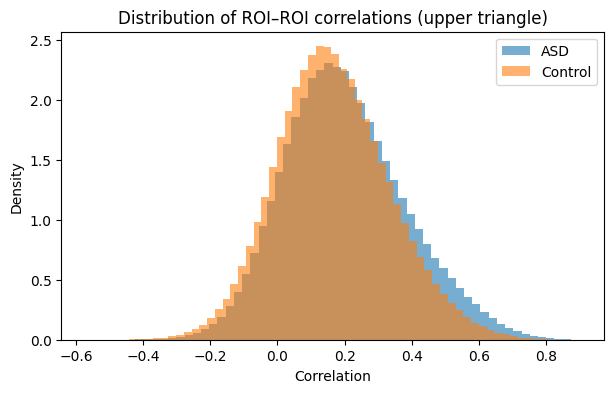

ASD  corr mean±std : 0.2010757250754808 0.18027394839785285
CTRL corr mean±std: 0.16665747391412827 0.16819319841164357


In [67]:
def upper_vals(C):
    iu = np.triu_indices(C.shape[0], k=1)
    return C[iu]

asd_vals  = np.concatenate([upper_vals(C_all_asd[i])  for i in range(C_all_asd.shape[0])])
ctrl_vals = np.concatenate([upper_vals(C_all_ctrl[i]) for i in range(C_all_ctrl.shape[0])])

plt.figure(figsize=(7,4))
plt.hist(asd_vals, bins=60, alpha=0.6, density=True, label="ASD")
plt.hist(ctrl_vals, bins=60, alpha=0.6, density=True, label="Control")
plt.title("Distribution of ROI–ROI correlations (upper triangle)")
plt.xlabel("Correlation")
plt.ylabel("Density")
plt.legend()
plt.show()

print("ASD  corr mean±std :", np.mean(asd_vals),  np.std(asd_vals))
print("CTRL corr mean±std:", np.mean(ctrl_vals), np.std(ctrl_vals))


In [69]:
def subject_graph_metrics(G_list):
    rows = []
    for i, g in enumerate(G_list):
        d = {}
        d.update(graph_basic_features(g))
        d.update(clustering_features(g))
        d.update(path_based_features(g))
        d["subject_index"] = i
        rows.append(d)
    return pd.DataFrame(rows)

df_metrics_asd  = subject_graph_metrics(G_list_asd)
df_metrics_ctrl = subject_graph_metrics(G_list_ctrl)

df_metrics_asd["group"]  = "ASD"
df_metrics_ctrl["group"] = "Control"

df_metrics_all = pd.concat([df_metrics_asd, df_metrics_ctrl], ignore_index=True)
df_metrics_all.head()


,n_nodes,n_edges,density,mean_degree,max_degree,std_degree,n_connected_components,gcc_size,gcc_fraction,mean_clustering,clustering_per_node,avg_shortest_path,global_efficiency,subject_index,group
0,200,13171,0.661859,131.71,186,35.735639,1,200,1.000,0.802288,"[0.7482286254133207, 0.7665927568366593, 0.803...",1.338543,0.830863,0,ASD
1,200,6848,0.344121,68.48,145,32.227932,1,200,1.000,0.623367,"[0.6915322580645161, 0.6883116883116883, 0.648...",1.688543,0.666633,1,ASD
2,200,3186,0.160101,31.86,63,14.063442,2,199,0.995,0.467822,"[0.42045454545454547, 0.5281385281385281, 0.47...",2.043653,0.546927,2,ASD
3,200,6149,0.308995,61.49,123,27.594925,1,200,1.000,0.590813,"[0.5968421052631578, 0.5716440422322775, 0.482...",1.724724,0.648878,3,ASD
4,200,12798,0.643116,127.98,187,40.558225,1,200,1.000,0.810603,"[0.8072289156626506, 0.878919553728714, 0.8706...",1.359950,0.821047,4,ASD


In [71]:
# --------- FIX: compare ONLY scalar metrics (exclude array-valued columns) ---------

def is_scalar_number(x):
    return np.isscalar(x) and isinstance(x, (int, float, np.number))

def perm_test_diff(a, b, n_perm=3000, seed=1):
    rng = np.random.default_rng(seed)
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    obs = a.mean() - b.mean()
    pool = np.concatenate([a, b])
    nA = len(a)

    null = np.zeros(n_perm, dtype=float)
    for i in range(n_perm):
        perm = rng.permutation(pool)
        null[i] = perm[:nA].mean() - perm[nA:].mean()

    p = (np.sum(np.abs(null) >= abs(obs)) + 1) / (n_perm + 1)
    return obs, p

# فقط ستون‌هایی که مقدار هر سلولشان عدد اسکالر است
candidate_cols = [c for c in df_metrics_asd.columns if c not in ["subject_index", "group"]]

scalar_metrics = []
for c in candidate_cols:
    # یک مقدار نمونه از هر گروه بردار
    x1 = df_metrics_asd[c].iloc[0]
    x2 = df_metrics_ctrl[c].iloc[0]
    if is_scalar_number(x1) and is_scalar_number(x2):
        scalar_metrics.append(c)

print("Scalar metrics used for comparison:", scalar_metrics)

rows = []
for m in scalar_metrics:
    a = df_metrics_asd[m].to_numpy(dtype=float)
    b = df_metrics_ctrl[m].to_numpy(dtype=float)

    diff, p = perm_test_diff(a, b, n_perm=3000, seed=42)
    rows.append({
        "metric": m,
        "ASD_mean": float(a.mean()),
        "ASD_std":  float(a.std()),
        "CTRL_mean": float(b.mean()),
        "CTRL_std":  float(b.std()),
        "diff_ASD_minus_CTRL": float(diff),
        "perm_p": float(p)
    })

df_graph_cmp = pd.DataFrame(rows).sort_values("perm_p")
df_graph_cmp


Scalar metrics used for comparison: ['n_nodes', 'n_edges', 'density', 'mean_degree', 'max_degree', 'std_degree', 'n_connected_components', 'gcc_size', 'gcc_fraction', 'mean_clustering', 'avg_shortest_path', 'global_efficiency']


,metric,ASD_mean,ASD_std,CTRL_mean,CTRL_std,diff_ASD_minus_CTRL,perm_p
8,gcc_fraction,0.999000,0.003000,0.996667,0.005821,0.002333,0.066978
7,gcc_size,199.800000,0.600000,199.333333,1.164283,0.466667,0.076974
6,n_connected_components,1.200000,0.600000,1.633333,1.079609,-0.433333,0.084638
1,n_edges,7320.433333,4048.528990,5983.233333,2756.327517,1337.200000,0.143952
3,mean_degree,73.204333,40.485290,59.832333,27.563275,13.372000,0.143952
2,density,0.367861,0.203444,0.300665,0.138509,0.067196,0.143952
11,global_efficiency,0.671894,0.112389,0.635401,0.081121,0.036493,0.156614
9,mean_clustering,0.619773,0.135567,0.579315,0.091879,0.040458,0.181606
10,avg_shortest_path,1.706611,0.275412,1.793161,0.217622,-0.086550,0.182939
4,max_degree,129.133333,42.365657,116.633333,36.298286,12.500000,0.224592


In [72]:
mean_pr_asd  = PR_asd.mean(axis=0)
mean_pr_ctrl = PR_ctrl.mean(axis=0)

df_pr_cmp = pd.DataFrame({
    "node": np.arange(len(mean_pr_asd)),
    "PR_ASD_mean": mean_pr_asd,
    "PR_CTRL_mean": mean_pr_ctrl,
    "diff_ASD_minus_CTRL": mean_pr_asd - mean_pr_ctrl
}).sort_values("diff_ASD_minus_CTRL", ascending=False)

df_pr_cmp.head(20)


,node,PR_ASD_mean,PR_CTRL_mean,diff_ASD_minus_CTRL
40,40,0.004021,0.002811,0.001210
116,116,0.006247,0.005045,0.001201
65,65,0.006374,0.005219,0.001154
8,8,0.006095,0.004966,0.001129
117,117,0.004480,0.003384,0.001096
153,153,0.004162,0.003200,0.000962
29,29,0.003789,0.002889,0.000900
36,36,0.006888,0.006028,0.000860
199,199,0.005728,0.004873,0.000855
193,193,0.003554,0.002724,0.000830


In [73]:
rng = np.random.default_rng(7)

S_a, N = PR_asd.shape
S_c, _ = PR_ctrl.shape

obs = PR_asd.mean(axis=0) - PR_ctrl.mean(axis=0)

pool = np.vstack([PR_asd, PR_ctrl])
labels = np.array([1]*S_a + [0]*S_c)

n_perm = 2000
null = np.zeros((n_perm, N))

for b in range(n_perm):
    perm = rng.permutation(labels)
    A = pool[perm == 1]
    C = pool[perm == 0]
    null[b] = A.mean(axis=0) - C.mean(axis=0)

pvals = np.zeros(N)
for j in range(N):
    pvals[j] = (np.sum(np.abs(null[:, j]) >= abs(obs[j])) + 1) / (n_perm + 1)

df_pr_nodewise = pd.DataFrame({
    "node": np.arange(N),
    "diff_PR_ASD_minus_CTRL": obs,
    "perm_p": pvals
}).sort_values(["perm_p", "diff_PR_ASD_minus_CTRL"], ascending=[True, False])

df_pr_nodewise.head(20)


,node,diff_PR_ASD_minus_CTRL,perm_p
108,108,-0.002099,0.000500
65,65,0.001154,0.001499
50,50,-0.001596,0.002499
153,153,0.000962,0.003498
116,116,0.001201,0.003998
138,138,-0.001219,0.004498
40,40,0.001210,0.010495
117,117,0.001096,0.012994
193,193,0.000830,0.013493
90,90,-0.001002,0.014993


In [74]:
cols = ["degree", "strength_abs", "betweenness", "eigenvector", "pagerank"]

df_cent_cmp = df_nodes.merge(
    df_nodes_ctrl,
    on="node",
    suffixes=("_ASD", "_CTRL")
)

for c in cols:
    df_cent_cmp[f"diff_{c}"] = df_cent_cmp[f"{c}_ASD"] - df_cent_cmp[f"{c}_CTRL"]

df_cent_cmp.sort_values("diff_pagerank", ascending=False).head(20)


,node,degree_ASD,strength_abs_ASD,betweenness_ASD,eigenvector_ASD,pagerank_ASD,degree_CTRL,strength_abs_CTRL,betweenness_CTRL,eigenvector_CTRL,pagerank_CTRL,diff_degree,diff_strength_abs,diff_betweenness,diff_eigenvector,diff_pagerank
29,29,178,36.816841,0.005338,0.087371,0.005545,77,13.740010,0.003619,0.049840,0.003264,101,23.076831,0.001719,0.037532,0.002281
40,40,148,30.742098,0.002577,0.075326,0.004727,69,13.180006,0.000574,0.047886,0.003049,79,17.562092,0.002003,0.027441,0.001678
116,116,178,45.903512,0.002968,0.088862,0.006576,114,25.403084,0.003377,0.074223,0.005104,64,20.500428,-0.000409,0.014639,0.001472
193,193,114,23.640681,0.001624,0.059188,0.003838,46,9.559700,0.001154,0.027687,0.002605,68,14.080981,0.000471,0.031500,0.001232
156,156,148,34.692697,0.001399,0.075725,0.005123,78,18.103290,0.000559,0.051123,0.003892,70,16.589407,0.000840,0.024602,0.001231
65,65,158,43.194368,0.001838,0.080250,0.006206,97,24.631288,0.001248,0.064578,0.004985,61,18.563080,0.000590,0.015672,0.001221
153,153,125,28.093411,0.000656,0.065618,0.004273,58,13.210366,0.000177,0.037174,0.003057,67,14.883045,0.000480,0.028444,0.001216
64,64,178,41.695390,0.002723,0.089047,0.006032,109,23.823404,0.001834,0.072091,0.004859,69,17.871986,0.000889,0.016956,0.001174
117,117,182,41.231357,0.004583,0.090388,0.006022,127,24.389436,0.003575,0.083726,0.004943,55,16.841921,0.001008,0.006661,0.001079
20,20,107,22.102212,0.000571,0.055808,0.003531,49,10.594029,0.000199,0.030994,0.002596,58,11.508183,0.000372,0.024814,0.000935


In [75]:
Gu_asd  = nx.Graph(G_mean_asd)
Gu_ctrl = nx.Graph(G_mean_ctrl)

bridges_asd  = set(nx.bridges(Gu_asd))
bridges_ctrl = set(nx.bridges(Gu_ctrl))

print("Number of bridges:")
print(" ASD :", len(bridges_asd))
print(" CTRL:", len(bridges_ctrl))

print("Shared bridges:", len(bridges_asd & bridges_ctrl))
print("ASD-only bridges:", list(bridges_asd - bridges_ctrl)[:20])
print("CTRL-only bridges:", list(bridges_ctrl - bridges_asd)[:20])


Number of bridges:
 ASD : 0
 CTRL: 0
Shared bridges: 0
ASD-only bridges: []
CTRL-only bridges: []


In [76]:
import os
os.makedirs("./outputs_compare", exist_ok=True)

df_graph_cmp.to_csv("./outputs_compare/graph_metrics_ASD_vs_CTRL.csv", index=False)
df_pr_cmp.to_csv("./outputs_compare/pagerank_mean_ASD_vs_CTRL.csv", index=False)
df_pr_nodewise.to_csv("./outputs_compare/pagerank_nodewise_perm_ASD_vs_CTRL.csv", index=False)
df_cent_cmp.to_csv("./outputs_compare/centrality_mean_graph_ASD_vs_CTRL.csv", index=False)

print("✅ All comparison outputs saved in ./outputs_compare/")


✅ All comparison outputs saved in ./outputs_compare/
